# Sampler Quickstart — Binary Lens Static

A minimal example of Bayesian sampling with `lcbinint`:

1. Generate synthetic binary-lens light curve with Gaussian noise
2. Build a `bayes.Model` with priors and flux marginalisation
3. Find the MAP estimate (Levenberg–Marquardt starting from the input parameters)
4. Initialize walkers using the Hessian at the MAP (`hessian_init=True`)
5. Run the ensemble sampler and inspect the posterior

In [1]:
import sys
from pathlib import Path

for build_dir in ("build", "build_new"):
    p = next(
        (r / build_dir for r in (Path.cwd(), *Path.cwd().parents) if (r / build_dir).is_dir()),
        None,
    )
    if p is not None:
        sys.path.insert(0, str(p))
        break

import numpy as np
import matplotlib.pyplot as plt
import lcbinint as lci

print("lcbinint:", lci.__file__)

lcbinint: /rogue1_8/nunota/lcbinint/build/lcbinint/__init__.py


## 1. Synthetic Data

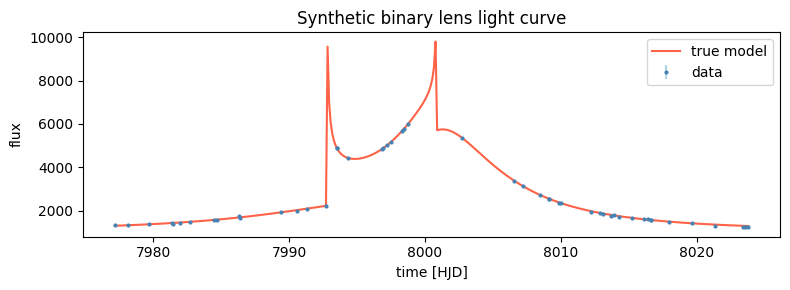

True parameters: {'t0': 8000.0, 'tE': 20.0, 'u0': 0.15, 's': 1.1, 'q': 0.05, 'alpha': 0.5}


In [2]:
rng = np.random.default_rng(42)

# Ground-truth parameters
TRUE = dict(t0=8000.0, tE=20.0, u0=0.15, s=1.1, q=0.05, alpha=0.5)
Fs_true, Fb_true, sigma = 1000.0, 50.0, 30.0

times = np.sort(rng.uniform(TRUE["t0"] - 25, TRUE["t0"] + 25, 50))
lc_ref   = lci.lc.LightCurve()
mag_true = lc_ref(times, **TRUE)
flux_true = Fs_true * mag_true + Fb_true
flux_obs  = flux_true + rng.normal(0, sigma, len(times))
flux_err  = np.full(len(times), sigma)

t_dense = np.linspace(times[0], times[-1], 400)
fig, ax = plt.subplots(figsize=(8, 3))
ax.errorbar(times, flux_obs, flux_err, fmt=".", ms=4, color="steelblue",
            ecolor="lightblue", label="data", zorder=3)
ax.plot(t_dense, Fs_true * lc_ref(t_dense, **TRUE) + Fb_true,
        color="tomato", lw=1.5, label="true model")
ax.set(xlabel="time [HJD]", ylabel="flux", title="Synthetic binary lens light curve")
ax.legend()
plt.tight_layout()
plt.show()
print("True parameters:", TRUE)

## 2. Model Setup

`model.flux()` analytically marginalises the linear flux parameters $F_s$ and $F_b$,  
so only the 6 lens parameters are sampled.

In [3]:
data     = lci.obs.LightCurveData(times, flux_obs, flux_err, name="synthetic")
lc_model = lci.lc.LightCurve()
model    = lci.bayes.Model(light_curve=lc_model, data=data)

model.param("t0",    lci.bayes.Uniform(7990, 8010))
model.param("tE",    lci.bayes.Uniform(5, 60))
model.param("u0",    lci.bayes.Uniform(0.0, 1.0))
model.param("s",     lci.bayes.Uniform(0.5, 2.0))
model.param("q",     lci.bayes.LogUniform(1e-3, 0.5))  # sampled in log space
model.param("alpha", lci.bayes.Uniform(0, np.pi))

model.flux()        # marginalise Fs, Fb analytically
model.likelihood()  # Gaussian likelihood

print("Params to sample:", model.param_names)

# Sanity check at truth (q is in log space for the sampler)
theta_true_s = [TRUE["t0"], TRUE["tE"], TRUE["u0"], TRUE["s"],
                np.log(TRUE["q"]), TRUE["alpha"]]
print(f"log_prob at truth: {model.log_prob(theta_true_s):.2f}")
print(f"chi2     at truth: {model.chi2(theta_true_s):.2f}  (n_data={model.n_data})")

Params to sample: ['t0', 'tE', 'u0', 's', 'q', 'alpha']
log_prob at truth: -24.67
chi2     at truth: 28.58  (n_data=50)


## 3. MAP Estimate (Levenberg–Marquardt)

Binary lens posteriors are sharply peaked and multimodal.  
Starting the sampler from a random draw of the prior leads to very poor mixing.

Instead we first refine the known input parameters to the MAP with Levenberg–Marquardt,  
then use the Hessian at the MAP to initialise the walkers (`hessian_init=True`).

In [4]:
lm      = lci.optimize.LevenbergMarquardt()
res_map = lm.minimize(model, start=theta_true_s)

print(f"LM success={res_map.success}  chi2={res_map.chi2:.4f}  log_prob={res_map.log_prob:.4f}")
print("MAP parameters:")
for k, v in res_map.parameters.items():
    print(f"  {k:6s}: {v:.5f}   (truth: {TRUE[k]:.5f})")

LM success=True  chi2=22.3188  log_prob=-21.5396
MAP parameters:
  alpha : 0.49659   (truth: 0.50000)
  s     : 1.08794   (truth: 1.10000)
  u0    : 0.14567   (truth: 0.15000)
  q     : 0.05087   (truth: 0.05000)
  tE    : 20.41735   (truth: 20.00000)
  t0    : 7999.96290   (truth: 8000.00000)


## 4. MCMC Sampling

`hessian_init=True` computes the Hessian of the negative log-posterior at `res_map`  
and disperses walkers according to the resulting Laplace covariance.  
This gives a well-scaled starting distribution with no manual tuning.

32 walkers, 100 burn-in + 300 production steps (~1 s total).

In [5]:
opts  = lci.SamplerOptions(nwalkers=32, log_every=50, auto_stop=False)
chain = lci.run_sampler(model, nsteps=300, burnin=100,
                        start=res_map, hessian_init=True, options=opts)

print(chain)
print(f"Acceptance fraction: {chain.acceptance_fraction:.3f}  (ideal ≈ 0.2–0.4)")

lcbinint sampler | 32 walkers | 6 params | burnin=100 | nsteps=300


  [burnin  50/100]  accept=0.237


  [burnin 100/100]  accept=0.243


  Burnin done. Starting production run.


  [step  50/300]  accept=0.245  log_prob=-26.22  elapsed=0.2s


...

  [step 200/300]  accept=0.241  log_prob=-25.32  elapsed=0.4s


  [step 250/300]  accept=0.240  log_prob=-25.32  elapsed=0.4s


  [step 300/300]  accept=0.238  log_prob=-25.96  elapsed=0.5s


  Done. 300 production steps | accept=0.238 | elapsed=0.5s


<sample.Chain nsteps=300 nwalkers=32 ndim=6 acceptance=0.237>
Acceptance fraction: 0.238  (ideal ≈ 0.2–0.4)


## 5. Chain Traces

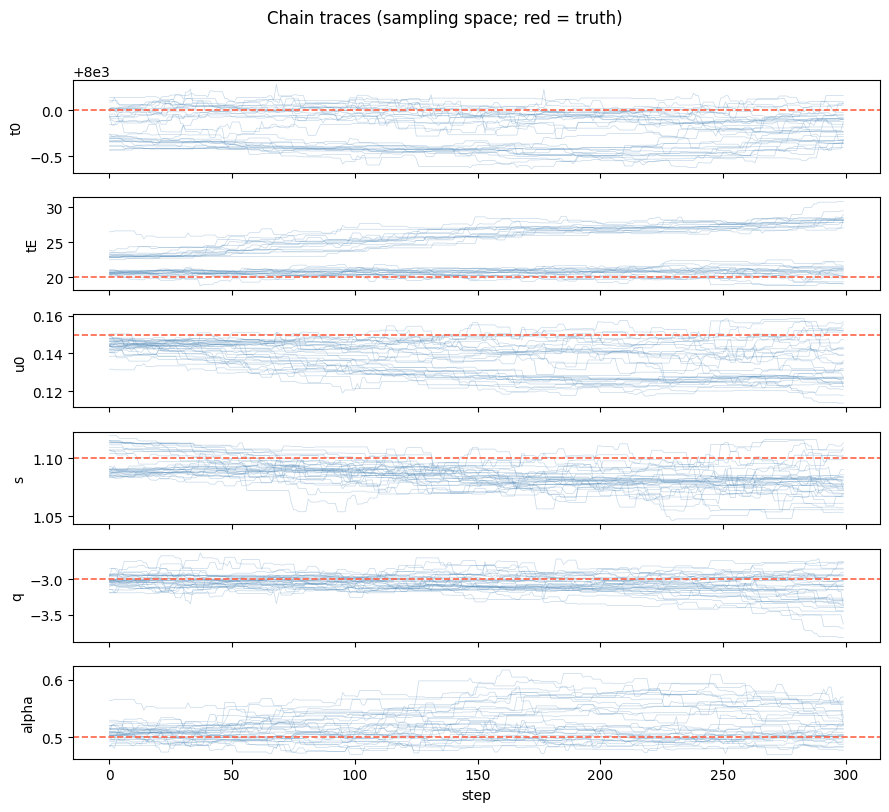

In [6]:
labels     = model.param_names
transforms = chain.transforms          # ["" or "log"] per param
chain_3d   = chain.get_chain()         # (nsteps, nwalkers, ndim) — sampling space
true_vals  = [TRUE["t0"], TRUE["tE"], TRUE["u0"], TRUE["s"], TRUE["q"], TRUE["alpha"]]

fig, axes = plt.subplots(len(labels), 1, figsize=(9, 8), sharex=True)
for i, (ax, lbl, tv) in enumerate(zip(axes, labels, true_vals)):
    ax.plot(chain_3d[:, :, i], alpha=0.3, lw=0.5, color="steelblue")
    ax.set_ylabel(lbl)
    tv_s = np.log(tv) if (transforms and transforms[i] == "log") else tv
    ax.axhline(tv_s, color="tomato", lw=1.2, ls="--")
axes[-1].set_xlabel("step")
fig.suptitle("Chain traces (sampling space; red = truth)", y=1.01)
plt.tight_layout()
plt.show()

## 6. Posterior Marginals

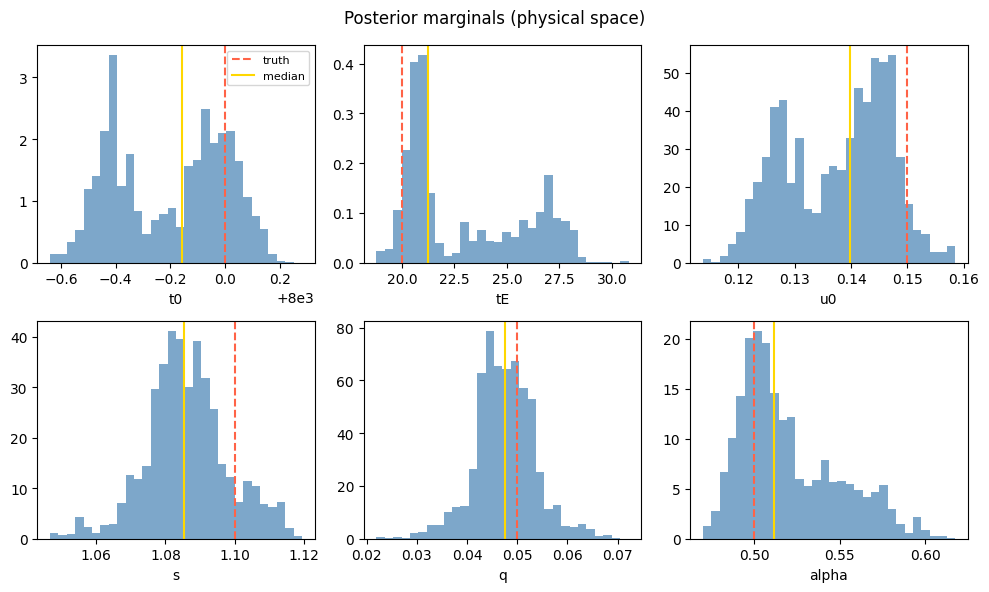

param      truth    median      16th      84th
t0      8000.0000  7999.8415  7999.5701  8000.0216
tE       20.0000   21.2640   20.4144   26.8905
u0        0.1500    0.1398    0.1266    0.1469
s         1.1000    1.0854    1.0764    1.0972
q         0.0500    0.0476    0.0427    0.0528
alpha     0.5000    0.5117    0.4938    0.5538


In [7]:
samples_phys = chain.samples   # (nsteps × nwalkers, ndim) — physical space

fig, axes = plt.subplots(2, 3, figsize=(10, 6))
for i, (ax, lbl, tv) in enumerate(zip(axes.flat, labels, true_vals)):
    ax.hist(samples_phys[:, i], bins=30, color="steelblue", alpha=0.7, density=True)
    ax.axvline(tv,                     color="tomato", lw=1.5, ls="--", label="truth")
    ax.axvline(np.median(samples_phys[:, i]), color="gold", lw=1.5, label="median")
    ax.set_xlabel(lbl)
    if i == 0:
        ax.legend(fontsize=8)

plt.suptitle("Posterior marginals (physical space)")
plt.tight_layout()
plt.show()

print(f"{'param':6s}  {'truth':>8s}  {'median':>8s}  {'16th':>8s}  {'84th':>8s}")
for lbl, tv in zip(labels, true_vals):
    s = chain.summary()[lbl]
    print(f"{lbl:6s}  {tv:8.4f}  {s['median']:8.4f}  {s['lo']:8.4f}  {s['hi']:8.4f}")

## 7. Best-Fit Overlay

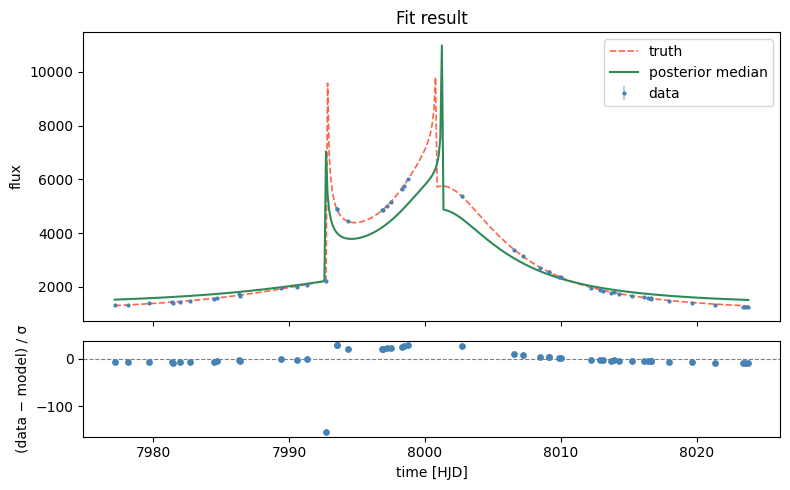

Recovered Fs = 699.8  (truth 1000.0)
Recovered Fb = 618.9  (truth 50.0)


In [8]:
summary = chain.summary()

# physical-space medians for light curve evaluation
p_med = {lbl: summary[lbl]["median"] for lbl in labels}

# sampling-space medians for flux extraction
theta_med_raw = np.median(chain.flat_samples, axis=0).tolist()
fluxes_med    = model.fluxes(theta_med_raw)
Fs_med = fluxes_med["synthetic"]["Fs"]
Fb_med = fluxes_med["synthetic"]["Fb"]

mag_med  = lc_model(t_dense, **p_med)
flux_med = Fs_med * mag_med + Fb_med

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 5), sharex=True,
                                gridspec_kw={"height_ratios": [3, 1]})
ax1.errorbar(times, flux_obs, flux_err, fmt=".", ms=4,
             color="steelblue", ecolor="lightblue", zorder=3, label="data")
ax1.plot(t_dense, Fs_true * lc_ref(t_dense, **TRUE) + Fb_true,
         color="tomato", lw=1.2, ls="--", label="truth")
ax1.plot(t_dense, flux_med, color="seagreen", lw=1.5, label="posterior median")
ax1.set_ylabel("flux")
ax1.set_title("Fit result")
ax1.legend()

flux_at_data = Fs_med * lc_model(times, **p_med) + Fb_med
ax2.scatter(times, (flux_obs - flux_at_data) / flux_err, s=15, color="steelblue", zorder=3)
ax2.axhline(0, color="gray", lw=0.8, ls="--")
ax2.set(xlabel="time [HJD]", ylabel="(data − model) / σ")
plt.tight_layout()
plt.show()

print(f"Recovered Fs = {Fs_med:.1f}  (truth {Fs_true:.1f})")
print(f"Recovered Fb = {Fb_med:.1f}  (truth {Fb_true:.1f})")